# Mental Health in the Tech Industry
## CS 210: Data Management for Data Science
**Authors:** Vanij Patel and Sean Lumasag

**Research Question:** What workplace and personal factors predict whether a tech worker will seek mental health treatment, and how does mental health interfere with their work?

**Datasets:** OSMI Mental Health in Tech Surveys — 2014 (1,259 rows) and 2016 (1,433 rows)

In [2]:
#imported libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, f1_score, accuracy_score)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import cross_val_score

os.makedirs('output_figures', exist_ok=True)

BLUE   = '#4C72B0'
ORANGE = '#DD8452'
GREEN  = '#2ca02c'

print("All libraries loaded.")

All libraries loaded.


---
## Stage 1 — Data Profiling & Inspection

We load both CSV files, store them in a SQLite database, and generate reports covering null rates, data types, and value distributions. This documents the baseline state of the data before any cleaning.


In [39]:
#read the csv files and stored them
df14 = pd.read_csv('2014.csv')
df16 = pd.read_csv('2016.csv')

#load the data into sqlite database
connect = sqlite3.connect('mental_health.db')
df14.to_sql('mental_health_2014', connect, if_exists='replace', index=False)
df16.to_sql('mental_health_2016', connect, if_exists='replace', index=False)

#print the number of rows and columns in each dataframe
print(f"2014: {df14.shape[0]} rows, {df14.shape[1]} columns")
print(f"2016: {df16.shape[0]} rows, {df16.shape[1]} columns")
print("\n Data successfully saved to 'mental_health.db'.")

2014: 1259 rows, 27 columns
2016: 1433 rows, 63 columns

 Data successfully saved to 'mental_health.db'.


In [40]:
#check for null values in each dataframe and print columns with >20% nulls
null14 = (df14.isnull().sum() / len(df14) * 100).round(1)
print("2014 Columns with >20% null values:")
print(null14[null14 > 20].sort_values(ascending=False))

2014 Columns with >20% null values:
comments          87.0
state             40.9
work_interfere    21.0
dtype: float64


In [41]:
#check for null values in each dataframe and print columns with >20% nulls
null16 = (df16.isnull().sum() / len(df16) * 100).round(1)
print("2016 Columns with >20% null values:")
print(null16[null16 > 20].sort_values(ascending=False))

2016 Columns with >20% null values:
If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?                                                        90.0
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?                                                85.8
Is your primary role within your company related to tech/IT?                                                                                                                        81.6
Do you know local or online resources to seek help for a mental health disorder?                                                                                                    80.0
If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?                                                        80.0
Do you have medical coverage (private i

In [42]:
#print the column names of each dataframe
print("2014 columns:", list(df14.columns))
print(f"\n2016 has {len(df16.columns)} columns written as longer questions.")
print("First 5 columns in 2016:")
print(list(df16.columns[:5]))

2014 columns: ['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments']

2016 has 63 columns written as longer questions.
First 5 columns in 2016:
['Are you self-employed?', 'How many employees does your company or organization have?', 'Is your employer primarily a tech company/organization?', 'Is your primary role within your company related to tech/IT?', 'Does your employer provide mental health benefits as part of healthcare coverage?']


---
## Stage 2 — Schema Alignment

The two surveys share no matching column names. The 2014 dataset uses short identifiers while 2016 uses full question text. We manually map each 2016 question to its 2014 equivalent, then add a `survey_year` column to both datasets before merging.


In [7]:
# Manual mapping: 2016 question text → 2014 column name
SCHEMA_MAP = {
    'Are you self-employed?': 'self_employed',
    'How many employees does your company or organization have?': 'no_employees',
    'Is your employer primarily a tech company/organization?': 'tech_company',
    'Does your employer provide mental health benefits as part of healthcare coverage?': 'benefits',
    'Do you know the options for mental health care available under your employer-provided coverage?': 'care_options',
    'Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?': 'wellness_program',
    'Does your employer offer resources to learn more about mental health concerns and options for seeking help?': 'seek_help',
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': 'anonymity',
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 'leave',
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?': 'mental_health_consequence',
    'Do you think that discussing a physical health issue with your employer would have negative consequences?': 'phys_health_consequence',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?': 'coworkers',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?': 'supervisor',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?': 'obs_consequence',
    'Would you bring up a mental health issue with a potential employer in an interview?': 'mental_health_interview',
    'Would you be willing to bring up a physical health issue with a potential employer in an interview?': 'phys_health_interview',
    'Do you feel that your employer takes mental health as seriously as physical health?': 'mental_vs_physical',
    'Do you have a family history of mental illness?': 'family_history',
    'Have you ever sought treatment for a mental health issue from a mental health professional?': 'treatment',
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': 'wi_treated',
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 'wi_untreated',
    'What is your age?': 'Age',
    'What is your gender?': 'Gender',
    'What country do you live in?': 'Country',
    'What US state or territory do you live in?': 'state',
    'Do you work remotely?': 'remote_work',
    'How willing would you be to share with friends and family that you have a mental illness?': 'share_friends_family',
}

# Align 2016 dataset to 2014 schema using the mapping
df16_aligned = df16.rename(columns=SCHEMA_MAP).copy()
df16_aligned['survey_year'] = 2016
unmapped = [c for c in df16.columns if c not in SCHEMA_MAP]
print("Unmapped 2016 columns:", unmapped)

df14_aligned = df14.copy()
df14_aligned['survey_year'] = 2014

print("Mapped " + str(len(SCHEMA_MAP)) + " columns from 2016 question text to 2014 names.")

print("survey_year column added to both datasets.")
print("Columns after alignment:", df16_aligned.columns)

Unmapped 2016 columns: ['Is your primary role within your company related to tech/IT?', 'Do you have medical coverage (private insurance or state-provided) which includes treatment of \xa0mental health issues?', 'Do you know local or online resources to seek help for a mental health disorder?', 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?', 'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?', 'If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?', 'If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?', 'Do you believe your productivity is ever affected by a mental health issue?', 'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental healt

---
## Stage 3 — Data Cleaning

We address five known data quality issues documented in the proposal:
1. **Age** — filter to 18–75, replace invalid values with the median
2. **Gender** — standardize 70+ freeform entries into Male, Female, Non-binary, Other
3. **Treatment** — encode Yes/No to 1/0 for 2014 (2016 is already binary)
4. **work_interfere** — fill 2014 nulls as Not Applicable; merge 2016's two interference columns using worst-case logic
5. **High-null columns** — drop any 2016 column with >80% missing values

In [8]:
#wrote a function to clean the Age column
def clean_age(df):
    df = df.copy()
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    df.loc[(df['Age'] < 18) | (df['Age'] > 75), 'Age'] = np.nan
    df['Age'] = df['Age'].fillna(df['Age'].median())
    return df

#clean the Age column in both datasets
df14_clean_age = clean_age(df14_aligned)
df16_clean_age = clean_age(df16_aligned)

print("Age column cleaned. Ages are between 18 and 75. Missing or invalid is filled with median.")

Age column cleaned. Ages are between 18 and 75. Missing or invalid is filled with median.


In [9]:
def standardize_gender(gender):
    if pd.isna(gender):
        return 'Other'
    
    gender = str(gender).lower().strip()

    if gender in ['f', 'fm', 'female']:
        return 'Female'
    if gender in ['m', 'male']:
        return 'Male'
    
    female_terms = [
        'woman', 'girl', 'femail', 'femake', 'cis f', 'cis-woman',
        'cisgender female', 'female assigned', 'i identify as female',
        'female or multi', 'female-bodied', 'female/woman', 'trans woman',
        'trans-female', 'transitioned, m2f', 'other/transfeminine',
        'transgender woman', 'genderflux demi-girl', 'fem', 'mtf'
    ]

    male_terms = [
        'man', 'boy', 'maile', 'msle', 'cis m', 'cisdude', 'dude',
        'sex is male', 'malr', 'mail', 'make', 'mal'
    ]

    nonbinary_terms = [
        'non-binary', 'nonbinary', 'agender', 'genderqueer', 'genderfluid',
        'fluid', 'enby', 'queer', 'androgyn', 'bigender',
        'nb masculine', 'genderflux', 'afab', 'male leaning androgynous',
        'male/genderqueer', 'neuter'
    ]
    
    for term in female_terms:
        if term in gender:
            return 'Female'

    for term in male_terms:
        if term in gender:
            return 'Male'

    for term in nonbinary_terms:
        if term in gender:
            return 'Non-binary'

    return 'Other'

df14_clean_age['Gender'] = df14_clean_age['Gender'].apply(standardize_gender)
df16_clean_age['Gender'] = df16_clean_age['Gender'].apply(standardize_gender)

print("2014:", df14_clean_age['Gender'].value_counts())
print("2016:", df16_clean_age['Gender'].value_counts())

2014: Gender
Male          994
Female        251
Non-binary      9
Other           5
Name: count, dtype: int64
2016: Gender
Male          1060
Female         348
Non-binary      18
Other            7
Name: count, dtype: int64


In [10]:
print("2016 is already encoded:",df16_clean_age['treatment'].unique())
df14_clean_age['treatment'] = df14_clean_age['treatment'].replace({'Yes': 1, 'No': 0})

print("2014 Treatment:", df14_clean_age['treatment'].value_counts())
print("2016 Treatment:", df16_clean_age['treatment'].value_counts())

2016 is already encoded: [0 1]
2014 Treatment: treatment
1    637
0    622
Name: count, dtype: int64
2016 Treatment: treatment
1    839
0    594
Name: count, dtype: int64


In [11]:
def normalize_yes_no(val):
    if pd.isna(val):
        return np.nan
    
    val = str(val).strip().lower()

    if val in ['1', 'yes', 'y', 'true']:
        return 'Yes'
    if val in ['0', 'no', 'n', 'false']:
        return 'No'
    return np.nan

df14_clean_age['self_employed'] = df14_clean_age['self_employed'].apply(normalize_yes_no)
df16_clean_age['self_employed'] = df16_clean_age['self_employed'].apply(normalize_yes_no)

def normalize_remote_work(val):
    if pd.isna(val):
        return np.nan
    
    val = str(val).strip().lower()

    if val in ['yes', 'always']:
        return 'Always'
    elif val in ['no', 'never']:
        return 'Never'
    elif val == 'sometimes':
        return 'Sometimes'
    return np.nan

df14_clean_age['remote_work'] = df14_clean_age['remote_work'].apply(normalize_remote_work)
df16_clean_age['remote_work'] = df16_clean_age['remote_work'].apply(normalize_remote_work)

print("2014 remote_work values:")
print(df14_clean_age['remote_work'].value_counts(dropna=False))

print("\n2016 remote_work values:")
print(df16_clean_age['remote_work'].value_counts(dropna=False))

print("\n2014 self_employed values:")
print(df14_clean_age['self_employed'].value_counts(dropna=False))

print("\n2016 self_employed values:")
print(df16_clean_age['self_employed'].value_counts(dropna=False))


2014 remote_work values:
remote_work
Never     883
Always    376
Name: count, dtype: int64

2016 remote_work values:
remote_work
Sometimes    757
Always       343
Never        333
Name: count, dtype: int64

2014 self_employed values:
self_employed
No     1095
Yes     146
NaN      18
Name: count, dtype: int64

2016 self_employed values:
self_employed
No     1146
Yes     287
Name: count, dtype: int64


In [12]:
df14_clean_age['work_interfere'] = df14_clean_age['work_interfere'].fillna('Not Applicable')
interference_rank = {
    'Often': 4, 
    'Sometimes': 3, 
    'Rarely': 2, 
    'Never': 1, 
    'Not Applicable': 0
    }

df16_clean_age['wi_treated'] = df16_clean_age['wi_treated'].replace('Not applicable to me', 'Not Applicable')
df16_clean_age['wi_untreated'] = df16_clean_age['wi_untreated'].replace('Not applicable to me', 'Not Applicable')

def get_worst_interference(row):
    treated = row.get('wi_treated')
    untreated = row.get('wi_untreated')

    if pd.isna(treated):
        treated = 'Not Applicable'
    if pd.isna(untreated):
        untreated = 'Not Applicable'

    treated_score = interference_rank.get(treated, 0)
    untreated_score = interference_rank.get(untreated, 0)

    if treated_score >= untreated_score:
        return treated
    return untreated

df16_clean_age['work_interfere'] = df16_clean_age.apply(get_worst_interference, axis=1)

print("2014 work_interfere:", df14_clean_age['work_interfere'].value_counts().to_dict())
print("2016 work_interfere:", df16_clean_age['work_interfere'].value_counts().to_dict())

2014 work_interfere: {'Sometimes': 465, 'Not Applicable': 264, 'Never': 213, 'Rarely': 173, 'Often': 144}
2016 work_interfere: {'Often': 547, 'Not Applicable': 452, 'Sometimes': 371, 'Rarely': 52, 'Never': 11}


In [13]:
# Drop 2016 columns with >80% nulls
null_pct_16 = df16_clean_age.isnull().sum() / len(df16_clean_age)
high_null = null_pct_16[null_pct_16 > 0.80].index.tolist()
df16_clean_age.drop(columns=high_null, inplace=True)

print(f"Dropped {len(high_null)} high-null columns from 2016.")
print("Columns removed:", high_null)

Dropped 3 high-null columns from 2016.
Columns removed: ['Is your primary role within your company related to tech/IT?', 'If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?', 'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?']


---
## Stage 4 — Merging & Validation

We select the shared aligned columns from both datasets and concatenate into a single DataFrame. We then validate by checking row counts, null rates, feature distributions, and class balance

In [14]:
# Normalize country names before merging (2014 uses 'United States of America')
df14_clean_age['Country'] = df14_clean_age['Country'].replace(
    'United States of America', 'United States')

df16_clean_age['Country'] = df16_clean_age['Country'].replace(
    'United States of America', 'United States')

SHARED = ['Age', 'Gender', 'Country', 'self_employed', 'family_history',
          'treatment', 'work_interfere', 'no_employees', 'remote_work',
          'tech_company', 'benefits', 'care_options', 'wellness_program',
          'seek_help', 'anonymity', 'leave', 'mental_health_consequence',
          'phys_health_consequence', 'coworkers', 'supervisor',
          'mental_health_interview', 'phys_health_interview',
          'mental_vs_physical', 'obs_consequence', 'survey_year',
          'share_friends_family']

cols14 = [c for c in SHARED if c in df14_clean_age.columns]
cols16 = [c for c in SHARED if c in df16_clean_age.columns]

df_merged = pd.concat([df14_clean_age[cols14], df16_clean_age[cols16]], ignore_index=True)

print(f"Merged shape: {df_merged.shape}")
print(f"Rows per year: {df_merged['survey_year'].value_counts().to_dict()}")
print(f"Treatment class balance: {df_merged['treatment'].value_counts().to_dict()}")

Merged shape: (2692, 26)
Rows per year: {2016: 1433, 2014: 1259}
Treatment class balance: {1: 1476, 0: 1216}


In [15]:
# Validate: check remaining null counts
print("Remaining null counts:")
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Remaining null counts:
self_employed                  18
no_employees                  287
tech_company                  287
benefits                      287
care_options                  420
wellness_program              287
seek_help                     287
anonymity                     287
leave                         287
mental_health_consequence     287
phys_health_consequence       287
coworkers                     287
supervisor                    287
mental_vs_physical            287
obs_consequence               287
share_friends_family         1259
dtype: int64


---
## Stage 5 — Feature Engineering & Encoding

We build two composite scores:
- **Employer Support Score** — averaged from 6 employer-related columns, normalized 0–1
- **Workplace Stigma Score** — averaged from 4 stigma/comfort columns, normalized 0–1

We also encode `work_interfere` as a numeric feature, apply MinMaxScaler to continuous features, and one-hot encode categorical columns.


In [16]:
# Save merged dataset to SQLite
df_merged.to_sql('merged_final', connect, if_exists='replace', index=False)

print("Merged dataset saved — SQLite table: merged_final")

Merged dataset saved — SQLite table: merged_final


In [17]:
df = df_merged.copy()

def score_response(val):
    if pd.isna(val):
        return np.nan
    
    val = str(val).lower().strip()
    
    score_map = {
        'yes': 1.0, 
        'no': 0.0,
        "don't know": 0.5, 
        "i don't know": 0.5,
        'not sure': 0.5, 
        'i am not sure': 0.5,
        'not eligible for coverage / n/a': 0.0,
        'very easy': 1.0, 
        'somewhat easy': 0.75,
        'neither easy nor difficult': 0.5,
        'somewhat difficult': 0.25, 
        'very difficult': 0.0
    }
    
    return score_map.get(val, np.nan)

support_cols = ['benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave']

for col in support_cols:
    new_col = col + '_score'
    df[new_col] = df[col].apply(score_response)

df['employer_support_score'] = df[[col + '_score' for col in support_cols]].mean(axis=1)

print("Support score mean:", df['employer_support_score'].mean().round(3))

Support score mean: 0.473


In [18]:
def score_stigma(val):
    if pd.isna(val):
        return np.nan
    
    val = str(val).lower().strip()
    
    score_map = {
        'yes': 1.0, 
        'no': 0.0,
        'maybe': 0.5, 
        'some of them': 0.5
    }
    
    return score_map.get(val)

stigma_cols = ['mental_health_consequence', 'obs_consequence']
comfort_cols = ['coworkers', 'supervisor']

for col in stigma_cols:
    df[col + '_score'] = df[col].apply(score_stigma)

for col in comfort_cols:
    df[col + '_score'] = df[col].apply(score_stigma).apply(lambda x: 1.0 - x if pd.notna(x) else np.nan)

df['stigma_score'] = df[[col + '_score' for col in stigma_cols + comfort_cols]].mean(axis=1)

print("Stigma score mean:", df['stigma_score'].mean().round(3))

Stigma score mean: 0.379


---
## SQL Queries — Database Component

We run four analytical SQL queries against the `merged_final` table to answer key questions before modeling.


In [19]:
# Q1: Treatment-seeking rate by year
q1 = pd.read_sql("""
    SELECT survey_year, 
    ROUND(AVG(CAST(treatment AS FLOAT)) * 100, 1) AS treatment_rate_pct,
    COUNT(*) AS total_respondents 
    FROM merged_final 
    WHERE treatment IS NOT NULL
    GROUP BY survey_year
""", connect)
print("Q1 — Treatment Rate by Year:")
q1

Q1 — Treatment Rate by Year:


,survey_year,treatment_rate_pct,total_respondents
0,2014,50.6,1259
1,2016,58.5,1433


In [20]:
# Q2: Treatment rate by company size
q2 = pd.read_sql("""
    SELECT no_employees, 
    ROUND(AVG(CAST(treatment AS FLOAT)) * 100, 1) AS treatment_rate_pct,
    COUNT(*) AS respondents FROM merged_final 
    WHERE treatment IS NOT NULL AND no_employees IS NOT NULL
    GROUP BY no_employees ORDER BY treatment_rate_pct DESC
""", connect)
print("Q2 — Treatment Rate by Company Size:")
q2

Q2 — Treatment Rate by Company Size:


,no_employees,treatment_rate_pct,respondents
0,100-500,57.3,424
1,More than 1000,56.3,538
2,1-5,55.9,222
3,26-100,53.9,581
4,500-1000,52.1,140
5,6-25,47.6,500


In [21]:
# Q3: Top 15 countries by respondent count and treatment rate
q3 = pd.read_sql("""
    SELECT Country, COUNT(*) AS respondents,ROUND(AVG(CAST(treatment AS FLOAT)) * 100, 1) AS treatment_rate_pct
    FROM merged_final
    WHERE treatment IS NOT NULL AND Country IS NOT NULL
    GROUP BY Country
    HAVING COUNT(*) >= 10
    ORDER BY respondents DESC
    LIMIT 15
""", connect)
print("Q3 — Top 15 Countries:")
q3

Q3 — Top 15 Countries:


,Country,respondents,treatment_rate_pct
0,United States,1591,60.3
1,United Kingdom,365,51.5
2,Canada,150,47.3
3,Germany,103,44.7
4,Netherlands,75,50.7
5,Australia,56,66.1
6,Ireland,42,47.6
7,France,29,24.1
8,Sweden,26,42.3
9,India,19,36.8


In [22]:
# Q4: Treatment rate by work interference level
q4 = pd.read_sql("""
    SELECT work_interfere, ROUND(AVG(CAST(treatment AS FLOAT)) * 100, 1) AS treatment_rate_pct,
    COUNT(*) AS count FROM merged_final 
    WHERE treatment IS NOT NULL GROUP BY work_interfere
    ORDER BY treatment_rate_pct DESC
""", connect)
print("Q4 — Treatment Rate by Work Interference Level:")
q4

Q4 — Treatment Rate by Work Interference Level:


,work_interfere,treatment_rate_pct,count
0,Often,88.1,691
1,Sometimes,73.8,836
2,Rarely,67.6,225
3,Never,15.6,224
4,Not Applicable,8.8,716


---
## Machine Learning

We train two classifiers to predict whether a tech worker will seek mental health treatment (`treatment = 1`):
- **Logistic Regression** — baseline model, interpretable coefficients
- **Random Forest** — primary model, feature importance scores

**Split:** 80% train / 20% test, stratified on the target variable. 5-fold cross-validation confirms results are stable.

In [23]:
# Encode work_interfere as numeric (key feature for ML)
interference_map = {
    'Often': 3, 
    'Sometimes': 2, 
    'Rarely': 1,
    'Never': 0, 
    'Not Applicable': np.nan
    }

df['work_interfere_num'] = df['work_interfere'].map(interference_map)

# One-hot encode categorical features
categorical_features = [c for c in ['Gender', 'no_employees', 'remote_work', 'family_history', 'self_employed'] if c in df.columns]

final_df = pd.get_dummies(df, columns=categorical_features)

final_df.to_sql('features_final', connect, if_exists='replace', index=False)

candidate_drop_cols = [
    'treatment', 'work_interfere', 'Country', 'state',
    'comments', 'Timestamp', 'share_friends_family'
]

raw_score_cols = [
    'benefits_score', 'care_options_score', 'wellness_program_score',
    'seek_help_score', 'anonymity_score', 'leave_score',
    'mental_health_consequence_score', 'obs_consequence_score',
    'coworkers_score', 'supervisor_score'
]

for col in raw_score_cols:
    if col in final_df.columns:
        candidate_drop_cols.append(col)

feature_cols = []
for col in final_df.columns:
    if col not in candidate_drop_cols and pd.api.types.is_numeric_dtype(final_df[col]):
        feature_cols.append(col)

df_ml = final_df[feature_cols + ['treatment']].dropna(subset=['treatment']).copy()

numeric_fill_cols = [
    c for c in ['Age', 'employer_support_score', 'stigma_score', 'work_interfere_num'] if c in df_ml.columns]

for col in numeric_fill_cols:
    df_ml[col] = df_ml[col].fillna(df_ml[col].median())

other_feature_cols = [c for c in feature_cols if c not in numeric_fill_cols]
df_ml[other_feature_cols] = df_ml[other_feature_cols].fillna(0)

X = df_ml[feature_cols].copy()
y = df_ml['treatment'].astype(int)

scale_cols = [c for c in ['Age', 'employer_support_score', 'stigma_score', 'work_interfere_num'] if c in X.columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train[scale_cols] = X_train[scale_cols].fillna(X_train[scale_cols].median())
X_test[scale_cols] = X_test[scale_cols].fillna(X_train[scale_cols].median())

scaler = MinMaxScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print("Final encoded dataset:", final_df.shape)
print("Features:", X.shape[1], "| Samples:", X.shape[0])
print("Train:", len(X_train), "| Test:", len(X_test))
print("Class balance:")
print("No Treatment:", (y == 0).sum())
print("Treatment:", (y == 1).sum())

Final encoded dataset: (2692, 52)
Features: 23 | Samples: 2692
Train: 2153 | Test: 539
Class balance:
No Treatment: 1216
Treatment: 1476


In [24]:
# Logistic Regression — Baseline
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

lr_cv = cross_val_score(
    LogisticRegression(max_iter=5000, random_state=42),
    X, y, 
    cv=5, 
    scoring='roc_auc'
).mean()

print("Logistic Regression")
print(f"Accuracy: {lr_acc:.3f} | F1: {lr_f1:.3f} | AUC: {lr_auc:.3f} | CV AUC: {lr_cv:.3f}")
print()
print(classification_report(y_test, lr_pred, target_names=['No Treatment', 'Treatment']))

Logistic Regression
Accuracy: 0.738 | F1: 0.761 | AUC: 0.795 | CV AUC: 0.791

              precision    recall  f1-score   support

No Treatment       0.71      0.72      0.71       243
   Treatment       0.76      0.76      0.76       296

    accuracy                           0.74       539
   macro avg       0.74      0.74      0.74       539
weighted avg       0.74      0.74      0.74       539



In [25]:
# Random Forest — Primary
# n_estimators=300, min_samples_leaf=2, max_features='sqrt' reduces overfitting
rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

rf_cv = cross_val_score(
    rf_model, 
    X, y, 
    cv=5, 
    scoring='roc_auc').mean()

feat_series = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("Random Forest")
print(f"Accuracy: {rf_acc:.3f} | F1: {rf_f1:.3f} | AUC: {rf_auc:.3f} | CV AUC: {rf_cv:.3f}")
print()
print(classification_report(y_test, rf_pred, target_names=['No Treatment', 'Treatment']))

Random Forest
Accuracy: 0.759 | F1: 0.782 | AUC: 0.827 | CV AUC: 0.810

              precision    recall  f1-score   support

No Treatment       0.74      0.72      0.73       243
   Treatment       0.78      0.79      0.78       296

    accuracy                           0.76       539
   macro avg       0.76      0.76      0.76       539
weighted avg       0.76      0.76      0.76       539



### Sub-experiment 1 — Personal vs Workplace Features

We train separate Random Forest models on personal features (age, gender, family history) and workplace features (employer support, stigma, work interference, benefits) to compare which group better predicts treatment-seeking by ROC-AUC.

In [26]:
personal_keywords = ['Age', 'Gender', 'family_history', 'self_employed', 'survey_year']
workplace_keywords = [
    'employer_support_score', 'stigma_score', 'work_interfere_num', 'no_employees',
    'mental_vs_physical', 'tech_company', 'remote_work'
]

personal_feature_cols = [ col for col in feature_cols if any(keyword in col for keyword in personal_keywords)]

workplace_feature_cols = [ col for col in feature_cols if any(keyword in col for keyword in workplace_keywords)]

X_train_personal = X_train[personal_feature_cols]
X_test_personal = X_test[personal_feature_cols]

X_train_workplace = X_train[workplace_feature_cols]
X_test_workplace = X_test[workplace_feature_cols]

personal_model = RandomForestClassifier( 
    n_estimators=300, 
    min_samples_leaf=2, 
    random_state=42)

personal_model.fit(X_train_personal, y_train)
personal_auc = roc_auc_score(y_test, personal_model.predict_proba(X_test_personal)[:, 1])

workplace_model = RandomForestClassifier( 
    n_estimators=300, 
    min_samples_leaf=2, 
    random_state=42)

workplace_model.fit(X_train_workplace, y_train)
workplace_auc = roc_auc_score(y_test, workplace_model.predict_proba(X_test_workplace)[:, 1])

print("Personal cols:", personal_feature_cols)
print("Workplace cols:", workplace_feature_cols)
print(f"Personal features ({len(personal_feature_cols)} columns) AUC: {personal_auc:.3f}")
print(f"Workplace features ({len(workplace_feature_cols)} columns) AUC: {workplace_auc:.3f}")

if personal_auc > workplace_auc:
    winner = "Personal"
else:
    winner = "Workplace"
print(f"\n{winner} features are stronger predictors of treatment-seeking.")

Personal cols: ['Age', 'survey_year', 'Gender_Female', 'Gender_Male', 'Gender_Non-binary', 'Gender_Other', "family_history_I don't know", 'family_history_No', 'family_history_Yes', 'self_employed_No', 'self_employed_Yes']
Workplace cols: ['employer_support_score', 'stigma_score', 'work_interfere_num', 'no_employees_1-5', 'no_employees_100-500', 'no_employees_26-100', 'no_employees_500-1000', 'no_employees_6-25', 'no_employees_More than 1000', 'remote_work_Always', 'remote_work_Never', 'remote_work_Sometimes']
Personal features (11 columns) AUC: 0.732
Workplace features (12 columns) AUC: 0.748

Workplace features are stronger predictors of treatment-seeking.


### Sub-experiment 2 — work_interfere as 4-Class Target

We predict how severely mental health interferes with work: Never / Rarely / Sometimes / Often.

In [27]:
valid_work_levels = ['Often', 'Sometimes', 'Rarely', 'Never']
df_work = final_df[final_df['work_interfere'].isin(valid_work_levels)].copy()

drop_cols_work = [
    'work_interfere',
    'work_interfere_num',
    'treatment',
    'Country', 
    'state',
    'comments', 
    'Timestamp', 
    'share_friends_family'
]

label_encoder = LabelEncoder()
y_work = label_encoder.fit_transform(df_work['work_interfere'])

X_work = df_work.drop(columns=drop_cols_work, errors='ignore').copy()
X_work = pd.get_dummies(X_work)
X_work = X_work.fillna(0)

X_train_work, X_test_work, y_train_work, y_test_work = train_test_split( 
    X_work, 
    y_work, 
    test_size=0.2, 
    stratify=y_work, 
    random_state=42
)

work_model = RandomForestClassifier(
    n_estimators=300, 
    class_weight='balanced', 
    random_state=42
)

work_model.fit(X_train_work, y_train_work)

work_pred = work_model.predict(X_test_work)
work_accuracy = accuracy_score(y_test_work, work_pred)

print(f"work_interfere 4-class Accuracy: {work_accuracy:.3f} (baseline: 0.250)")
print()
print(classification_report(y_test_work, work_pred, target_names=label_encoder.classes_))

work_interfere 4-class Accuracy: 0.543 (baseline: 0.250)

              precision    recall  f1-score   support

       Never       0.51      0.44      0.48        45
       Often       0.63      0.60      0.61       138
      Rarely       0.22      0.04      0.07        45
   Sometimes       0.51      0.65      0.57       168

    accuracy                           0.54       396
   macro avg       0.47      0.44      0.43       396
weighted avg       0.52      0.54      0.52       396



### Sub-experiment 3 — survey_year as a Feature

We examine where the year (2014 vs 2016) ranks in the Random Forest feature importance scores to understand if temporal differences are predictive.

In [28]:
# Random Forest — Sub-experiment 3 (survey_year importance)
year_feat_series = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

year_imp = year_feat_series.get('survey_year', 0)

if 'survey_year' in year_feat_series.index:
    year_rank = list(year_feat_series.index).index('survey_year') + 1
else:
    year_rank = 'N/A'

if year_rank == 'N/A':
    year_summary = 'survey_year is not present in the model feature set.'
elif year_rank <= 5:
    year_summary = 'survey_year is among the strongest predictors in this model.'
elif year_rank <= 10:
    year_summary = 'survey_year is a moderately important predictor in this model.'
else:
    year_summary = 'survey_year is a relatively weak predictor compared with the top features.'

print(f"survey_year importance score: {year_imp:.4f}")
print(f"survey_year rank: #{year_rank} out of {len(feature_cols)} features")
print(year_summary)
print()
print("Top 10 features by importance in this sub-experiment:")
print(year_feat_series.head(10).to_string())

survey_year importance score: 0.0230
survey_year rank: #8 out of 23 features
survey_year is a moderately important predictor in this model.

Top 10 features by importance in this sub-experiment:
work_interfere_num        0.199556
Age                       0.156452
employer_support_score    0.133621
family_history_No         0.096326
family_history_Yes        0.093699
stigma_score              0.088254
Gender_Male               0.026034
survey_year               0.022987
Gender_Female             0.021313
remote_work_Always        0.017594


---
## Visualizations

Ten visualizations covering all areas from the proposal.


### Vis 1 — Treatment-Seeking Rate by Country

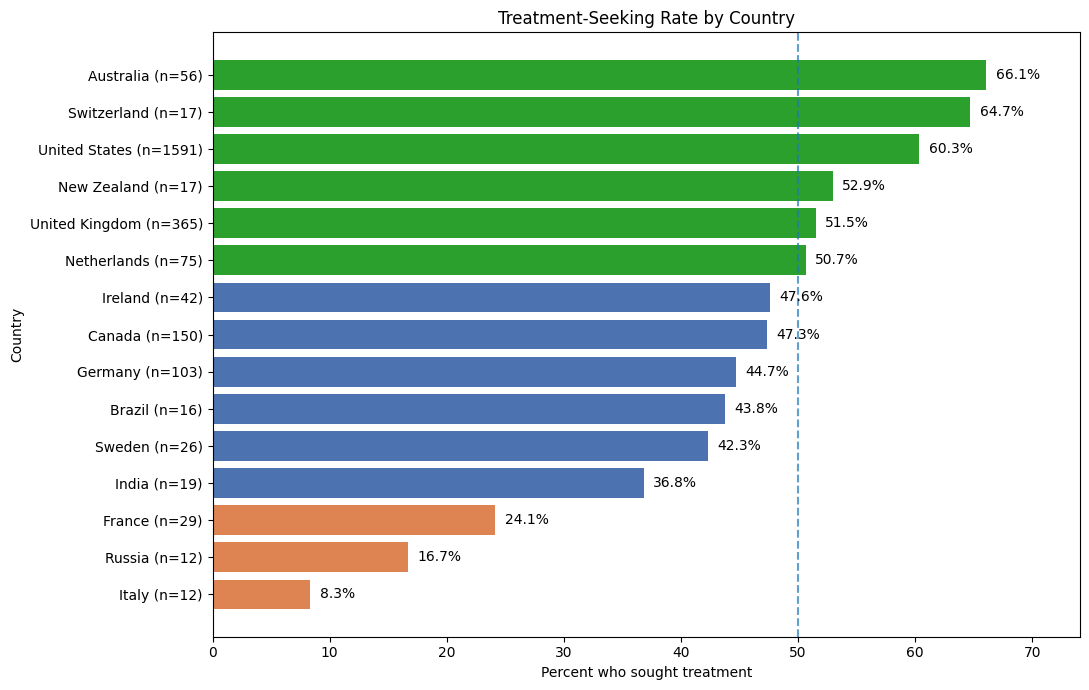

In [29]:
country_treat = df_merged[df_merged['treatment'].notna()].copy()

country_treat = (
    country_treat.groupby('Country')['treatment']
    .agg(['mean', 'count'])
    .reset_index()
)
country_treat.columns = ['Country', 'treatment_rate', 'count']
country_treat = country_treat[country_treat['count'] >= 10]
country_treat = country_treat.sort_values(by=['count', 'treatment_rate'], ascending=[False, False])
country_treat = country_treat.head(15)
country_treat = country_treat.sort_values(by='treatment_rate')

labels = []
for i in range(len(country_treat)):
    country = country_treat.iloc[i]['Country']
    count = country_treat.iloc[i]['count']
    labels.append(f"{country} (n={count})")

values = country_treat['treatment_rate'] * 100
colors = []
for val in values:
    if val >= 50:
        colors.append(GREEN)
    elif val >= 30:
        colors.append(BLUE)
    else:
        colors.append(ORANGE)
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(labels, values, color=colors)

for i, bar in enumerate(bars):
    value = values.iloc[i]
    ax.text(
        value + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va='center'
    )

ax.axvline(50, linestyle='--', alpha=0.7)
ax.set_title('Treatment-Seeking Rate by Country')
ax.set_xlabel('Percent who sought treatment')
ax.set_ylabel('Country')
ax.set_xlim(0, values.max() + 8)
plt.tight_layout()
plt.savefig('output_figures/vis1_treatment_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 2 — Year-over-Year Comparison (Treatment Rate, Employer Support, Stigma)

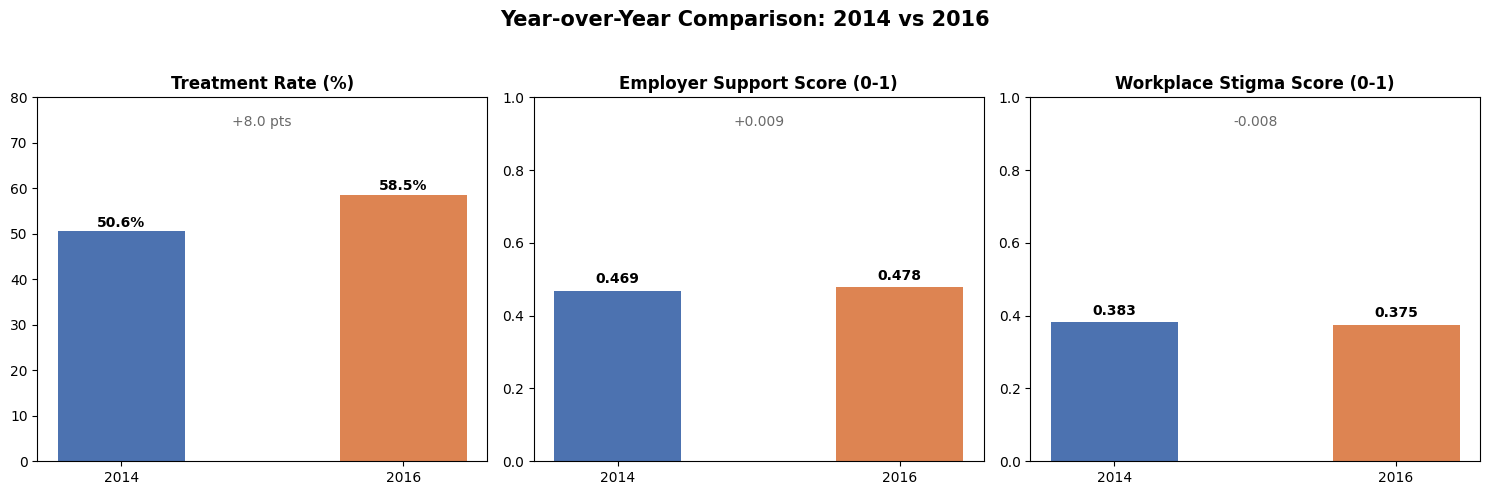

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Year-over-Year Comparison: 2014 vs 2016', fontsize=15, fontweight='bold')

years = [2014, 2016]
series_info = [
    ('Treatment Rate (%)', (df.groupby('survey_year')['treatment'].mean() * 100).reindex(years), '{:.1f}%', 80, 'pct'),
    ('Employer Support Score (0-1)', df.groupby('survey_year')['employer_support_score'].mean().reindex(years), '{:.3f}', 1.0, 'score'),
    ('Workplace Stigma Score (0-1)', df.groupby('survey_year')['stigma_score'].mean().reindex(years), '{:.3f}', 1.0, 'score')
]

for ax, (title, values, label_fmt, upper_limit, metric_type) in zip(axes, series_info):
    bars = ax.bar(['2014', '2016'], values.values, color=[BLUE, ORANGE], width=0.45)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0, upper_limit)
    for bar, value in zip(bars, values.values):
        offset = 1 if metric_type == 'pct' else 0.02
        ax.text(bar.get_x() + bar.get_width() / 2, value + offset, label_fmt.format(value), ha='center', fontweight='bold')
    delta = values.iloc[1] - values.iloc[0]
    delta_text = f'{delta:+.1f} pts' if metric_type == 'pct' else f'{delta:+.3f}'
    ax.text(0.5, 0.92, delta_text, transform=ax.transAxes, ha='center', fontsize=10, color='dimgray')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('output_figures/vis2_year_over_year.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 3 — Treatment-Seeking Rate by Employer Support Score Bin

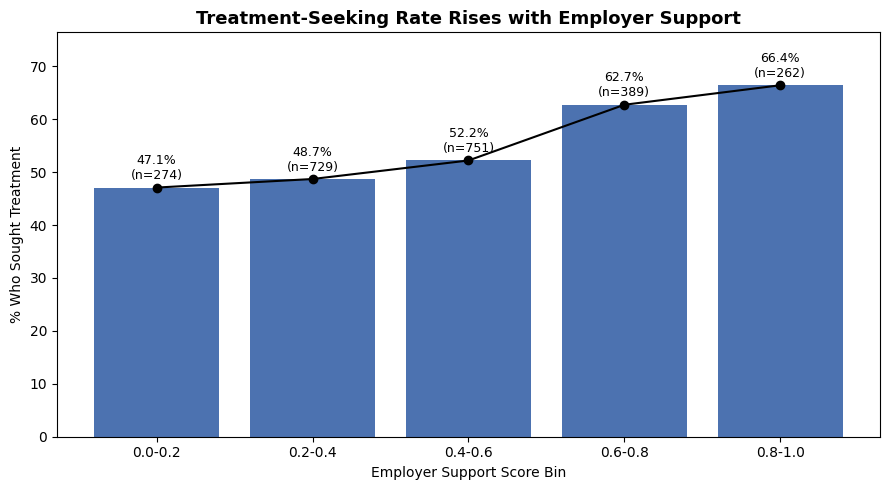

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
df_plot = df.dropna(subset=['employer_support_score']).copy()
df_plot['treatment_num'] = pd.to_numeric(df_plot['treatment'], errors='coerce')
df_plot = df_plot.dropna(subset=['treatment_num']).copy()

bin_edges = np.linspace(0, 1, 6)
df_plot['support_bin'] = pd.cut(df_plot['employer_support_score'], bins=bin_edges, include_lowest=True)
bin_summary = (
    df_plot.groupby('support_bin')
    .agg(treatment_rate=('treatment_num', 'mean'), respondents=('treatment_num', 'size'))
    .reset_index()
)

bin_labels = ['0.0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0']
bar_heights = bin_summary['treatment_rate'] * 100

bars = ax.bar(bin_labels, bar_heights, color=BLUE)
ax.plot(bin_labels, bar_heights, color='black', marker='o')

for i in range(len(bars)):
    bar = bars[i]
    rate = bin_summary.iloc[i]['treatment_rate']
    n = bin_summary.iloc[i]['respondents']
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{rate * 100:.1f}%\n(n={n})',
        ha='center',
        va='bottom',
        fontsize=9
    )
    
ax.set_title('Treatment-Seeking Rate Rises with Employer Support', fontsize=13, fontweight='bold')
ax.set_xlabel('Employer Support Score Bin')
ax.set_ylabel('% Who Sought Treatment')
ax.set_ylim(0, max(bar_heights) + 10)
plt.tight_layout()
plt.savefig('output_figures/vis3_employer_support_bins.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 4 — Workplace Stigma Score vs Treatment Avoidance (Grouped Bar)

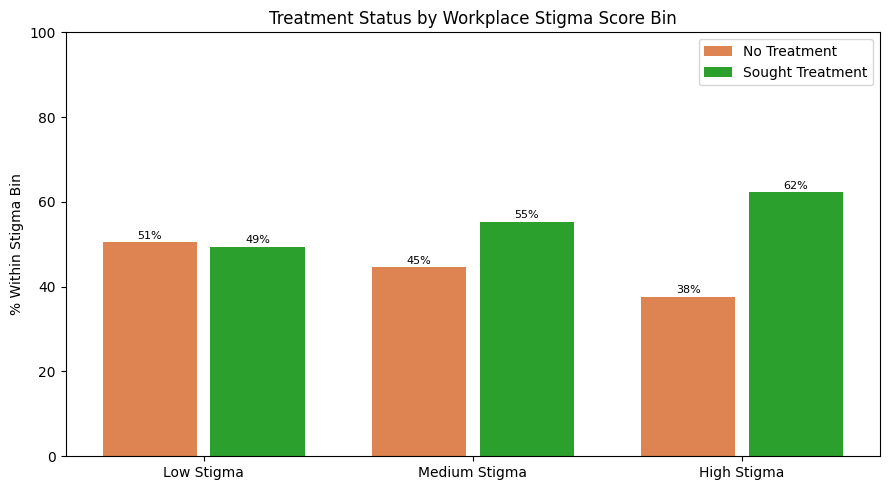

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
stigma_labels = ['Low Stigma', 'Medium Stigma', 'High Stigma']

df_plot4 = df.dropna(subset=['stigma_score', 'treatment']).copy()
df_plot4['stigma_group'] = pd.cut(
    df_plot4['stigma_score'],
    bins=[0, 0.33, 0.66, 1.01],
    labels=stigma_labels,
    include_lowest=True
)

grouped = df_plot4.groupby(['stigma_group', 'treatment']).size().unstack(fill_value=0)
grouped = grouped.reindex(stigma_labels)
grouped = grouped.reindex(columns=[0, 1], fill_value=0)
grouped.columns = ['No Treatment', 'Sought Treatment']
grouped_pct = grouped.div(grouped.sum(axis=1), axis=0).fillna(0) * 100
x = np.arange(len(stigma_labels))

bars_no = ax.bar(x - 0.2, grouped_pct['No Treatment'], 0.35, color=ORANGE, label='No Treatment')
bars_yes = ax.bar(x + 0.2, grouped_pct['Sought Treatment'], 0.35, color=GREEN, label='Sought Treatment')

ax.set_xticks(x)
ax.set_xticklabels(stigma_labels)
ax.set_title('Treatment Status by Workplace Stigma Score Bin')
ax.set_ylabel('% Within Stigma Bin')
ax.set_ylim(0, 100)
ax.legend()

for bar in bars_no:
    if bar.get_height() > 3:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{bar.get_height():.0f}%',
            ha='center',
            fontsize=8
        )

for bar in bars_yes:
    if bar.get_height() > 3:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{bar.get_height():.0f}%',
            ha='center',
            fontsize=8
        )
plt.tight_layout()
plt.savefig('output_figures/vis4_stigma_vs_treatment.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 5 — Willingness to Discuss Mental Health by Relationship Type

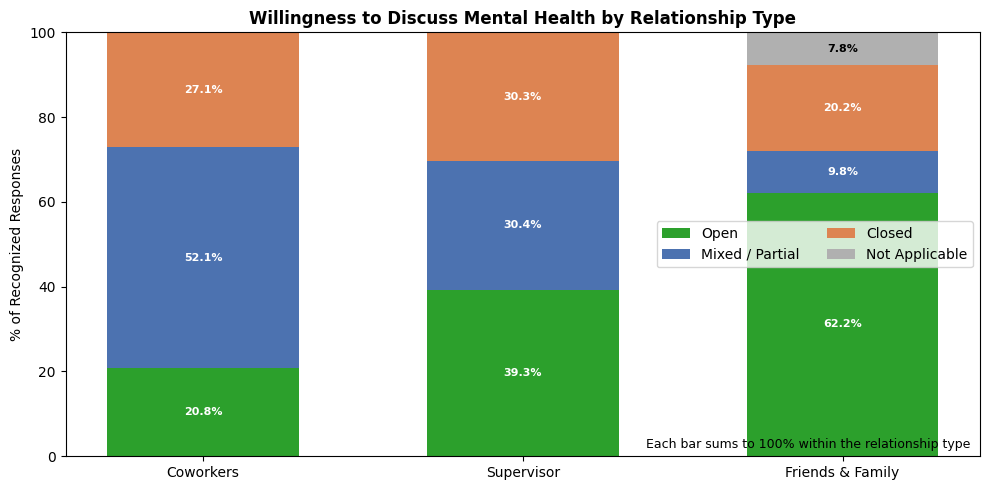

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
response_groups = {
    'Coworkers': (
        'coworkers',
        {
            'Open': ['yes'],
            'Mixed / Partial': ['maybe', 'some of them'],
            'Closed': ['no'],
        }
    ),
    'Supervisor': (
        'supervisor',
        {
            'Open': ['yes'],
            'Mixed / Partial': ['maybe', 'some of them'],
            'Closed': ['no'],
        }
    ),
    'Friends & Family': (
        'share_friends_family',
        {
            'Open': ['very open', 'somewhat open'],
            'Mixed / Partial': ['neutral'],
            'Closed': ['somewhat not open', 'not open at all'],
            'Not Applicable': ['not applicable to me (i do not have a mental illness)']
        }
    )
}
category_order = ['Open', 'Mixed / Partial', 'Closed', 'Not Applicable']
category_colors = {
    'Open': GREEN,
    'Mixed / Partial': BLUE,
    'Closed': ORANGE,
    'Not Applicable': '#B0B0B0'
}
summary = []

for label, (column, mapping) in response_groups.items():
    responses = df_merged[column].dropna().astype(str).str.strip().str.lower()
    classified = pd.Series('Unclassified', index=responses.index)
    for category, match_values in mapping.items():
        if match_values:
            classified.loc[responses.isin(match_values)] = category
    recognized = classified[classified != 'Unclassified']
    total = len(recognized)
    summary.append({
        'relationship': label,
        **{category: (recognized == category).mean() * 100 if total else 0 for category in category_order}
    })

summary_df = pd.DataFrame(summary)
x = np.arange(len(summary_df))
bottom = np.zeros(len(summary_df))
for category in category_order:
    bars = ax.bar(x, summary_df[category], bottom=bottom, color=category_colors[category], width=0.6, label=category)
    for bar, value, base in zip(bars, summary_df[category], bottom):
        if value >= 6:
            ax.text(bar.get_x() + bar.get_width() / 2, base + value / 2, f'{value:.1f}%', ha='center', va='center', fontsize=8, color='white' if category != 'Not Applicable' else 'black', fontweight='bold')
    bottom += summary_df[category].values
ax.set_xticks(x)
ax.set_xticklabels(summary_df['relationship'])
ax.set_title('Willingness to Discuss Mental Health by Relationship Type', fontsize=12, fontweight='bold')
ax.set_ylabel('% of Recognized Responses')
ax.set_ylim(0, 100)
ax.legend(ncol=2)
ax.text(0.99, 0.02, 'Each bar sums to 100% within the relationship type', transform=ax.transAxes, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('output_figures/vis5_discuss_by_relationship.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 6 — Top 15 Feature Importances (Random Forest)

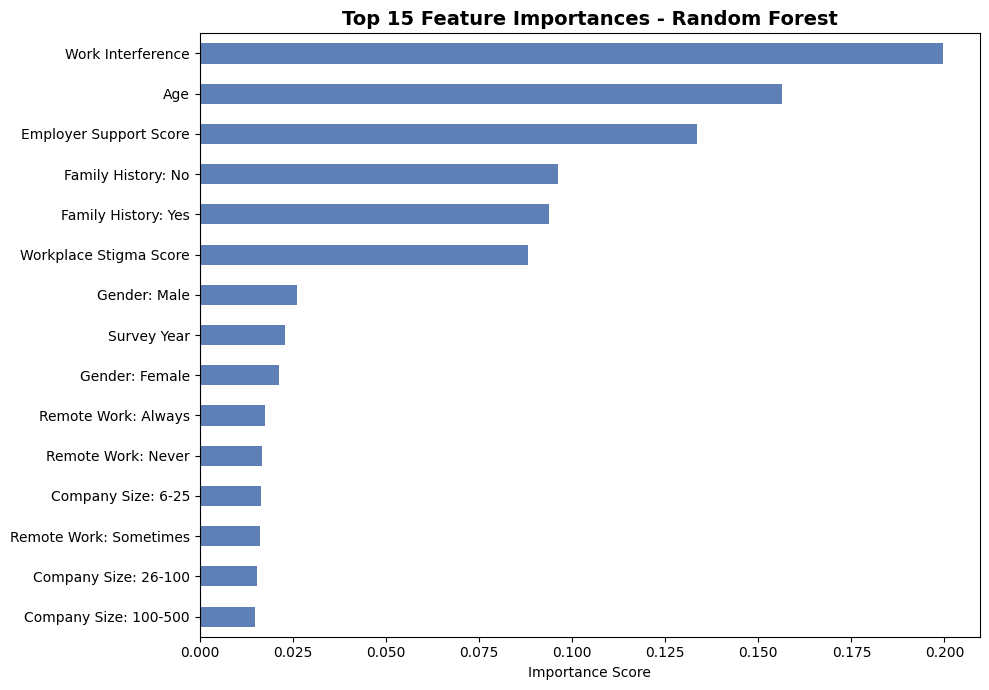

In [34]:
fig, ax = plt.subplots(figsize=(10, 7))
top_features = feat_series.head(15).sort_values().copy()
feature_label_map = {
    'work_interfere_num': 'Work Interference',
    'Age': 'Age',
    'employer_support_score': 'Employer Support Score',
    'family_history_No': 'Family History: No',
    'family_history_Yes': 'Family History: Yes',
    'stigma_score': 'Workplace Stigma Score',
    'Gender_Male': 'Gender: Male',
    'Gender_Female': 'Gender: Female',
    'survey_year': 'Survey Year',
    'remote_work_Always': 'Remote Work: Always',
    'remote_work_Never': 'Remote Work: Never',
    'remote_work_Sometimes': 'Remote Work: Sometimes',
    'no_employees_6-25': 'Company Size: 6-25',
    'no_employees_26-100': 'Company Size: 26-100',
    'no_employees_100-500': 'Company Size: 100-500'
}
top_features.index = [feature_label_map.get(feature, feature.replace('_', ' ')) for feature in top_features.index]
top_features.plot(kind='barh', ax=ax, color=BLUE, alpha=0.9)
ax.set_title('Top 15 Feature Importances - Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('output_figures/vis6_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 7 — Model Performance Comparison (F1 and AUC)

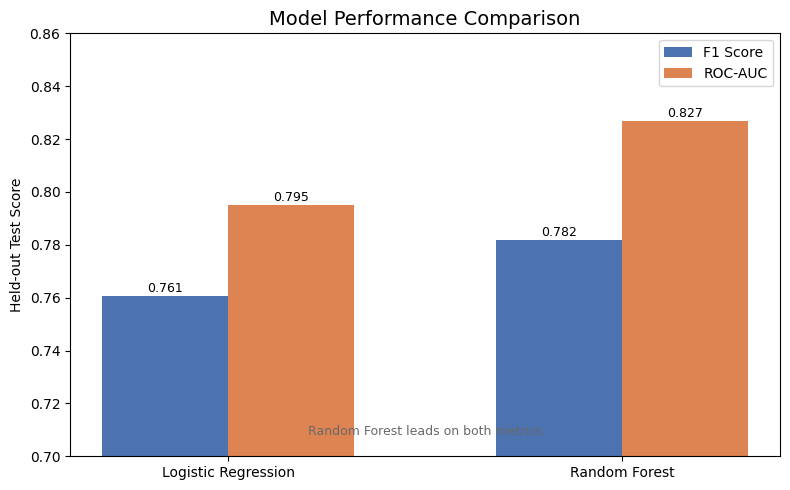

In [35]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
b1 = ax.bar(x - 0.16, [lr_f1, rf_f1], 0.32, label='F1 Score', color=BLUE)
b2 = ax.bar(x + 0.16, [lr_auc, rf_auc], 0.32, label='ROC-AUC', color=ORANGE)
ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'Random Forest'])
ax.set_ylim(0.70, 0.86)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_ylabel('Held-out Test Score')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0015, f'{bar.get_height():.3f}', ha='center', fontsize=9)
ax.text(0.5, 0.05, 'Random Forest leads on both metrics', transform=ax.transAxes, ha='center', fontsize=9, color='dimgray')
plt.tight_layout()
plt.savefig('output_figures/vis7_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 8 — Confusion Matrices (Both Classifiers)

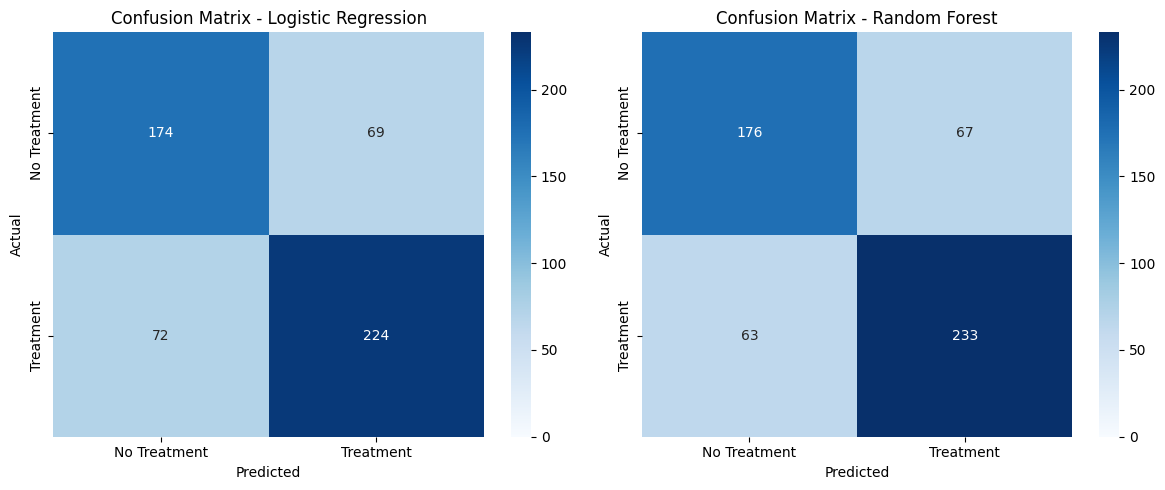

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_lr = confusion_matrix(y_test, lr_pred)
cm_rf = confusion_matrix(y_test, rf_pred)
common_max = max(cm_lr.max(), cm_rf.max())

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    vmin=0,
    vmax=common_max,
    xticklabels=['No Treatment', 'Treatment'],
    yticklabels=['No Treatment', 'Treatment']
)
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    vmin=0,
    vmax=common_max,
    xticklabels=['No Treatment', 'Treatment'],
    yticklabels=['No Treatment', 'Treatment']
)
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('output_figures/vis8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 9 — Personal vs Workplace AUC Comparison

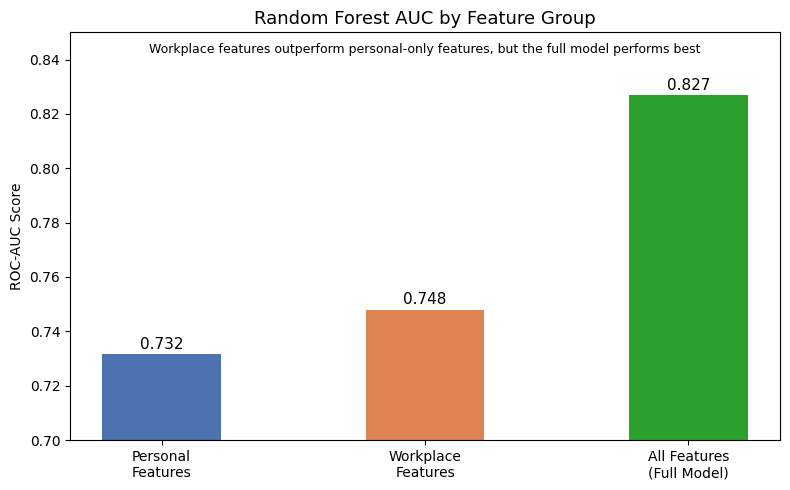

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Personal\nFeatures', 'Workplace\nFeatures', 'All Features\n(Full Model)']
aucs = [personal_auc, workplace_auc, rf_auc]
bar_clrs = [BLUE, ORANGE, GREEN]
bars = ax.bar(labels, aucs, color=bar_clrs, width=0.45)

ax.set_ylim(0.70, 0.85)
ax.set_title('Random Forest AUC by Feature Group', fontsize=13)
ax.set_ylabel('ROC-AUC Score')

for i in range(len(bars)):
    bar = bars[i]
    val = aucs[i]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center',
        fontsize=11
    )

ax.text(
    0.5,
    0.95,
    'Workplace features outperform personal-only features, but the full model performs best',
    transform=ax.transAxes,
    ha='center',
    fontsize=9
)

plt.tight_layout()
plt.savefig('output_figures/vis9_personal_vs_workplace_auc.png', dpi=150, bbox_inches='tight')
plt.show()

### Vis 10 — Age Distribution by Treatment Status

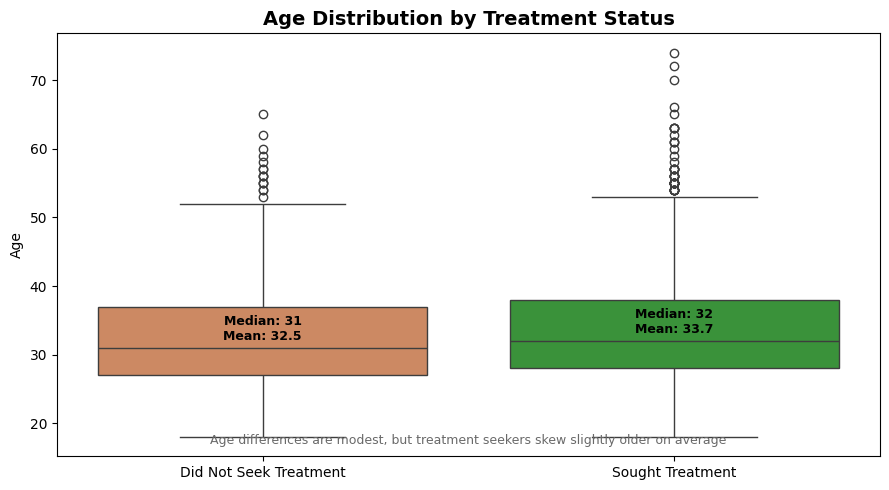

In [38]:
fig, ax = plt.subplots(figsize=(9, 5))
age_plot = df_merged.dropna(subset=['Age', 'treatment']).copy()
age_plot['Treatment Status'] = age_plot['treatment'].map({0: 'Did Not Seek Treatment', 1: 'Sought Treatment'})
sns.boxplot(data=age_plot, x='Treatment Status', y='Age', hue='Treatment Status', order=['Did Not Seek Treatment', 'Sought Treatment'], hue_order=['Did Not Seek Treatment', 'Sought Treatment'], palette=[ORANGE, GREEN], dodge=False, legend=False, ax=ax)
group_medians = age_plot.groupby('Treatment Status')['Age'].median().reindex(['Did Not Seek Treatment', 'Sought Treatment'])
group_means = age_plot.groupby('Treatment Status')['Age'].mean().reindex(['Did Not Seek Treatment', 'Sought Treatment'])
for idx, (status, median_value) in enumerate(group_medians.items()):
    ax.text(idx, median_value + 1.2, f'Median: {median_value:.0f}\nMean: {group_means[status]:.1f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Age Distribution by Treatment Status', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Age')
ax.text(0.5, 0.03, 'Age differences are modest, but treatment seekers skew slightly older on average', transform=ax.transAxes, ha='center', fontsize=9, color='dimgray')
plt.tight_layout()
plt.savefig('output_figures/vis10_age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()